In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

!pip install fredapi
!pip install ruptures
from fredapi import Fred
from statsmodels.tsa.seasonal import seasonal_decompose, STL, MSTL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt

np.random.seed(42)

FRED_API_KEY = '9dfe5827a52d6274b65c9f8c1054c90e'  # Get free key at fred.stlouisfed.org
fred = Fred(api_key=FRED_API_KEY)

print('Libraries loaded. Ready to diagnose.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.9 MB/s eta 0:00:00
Libraries loaded. Ready to diagnose.


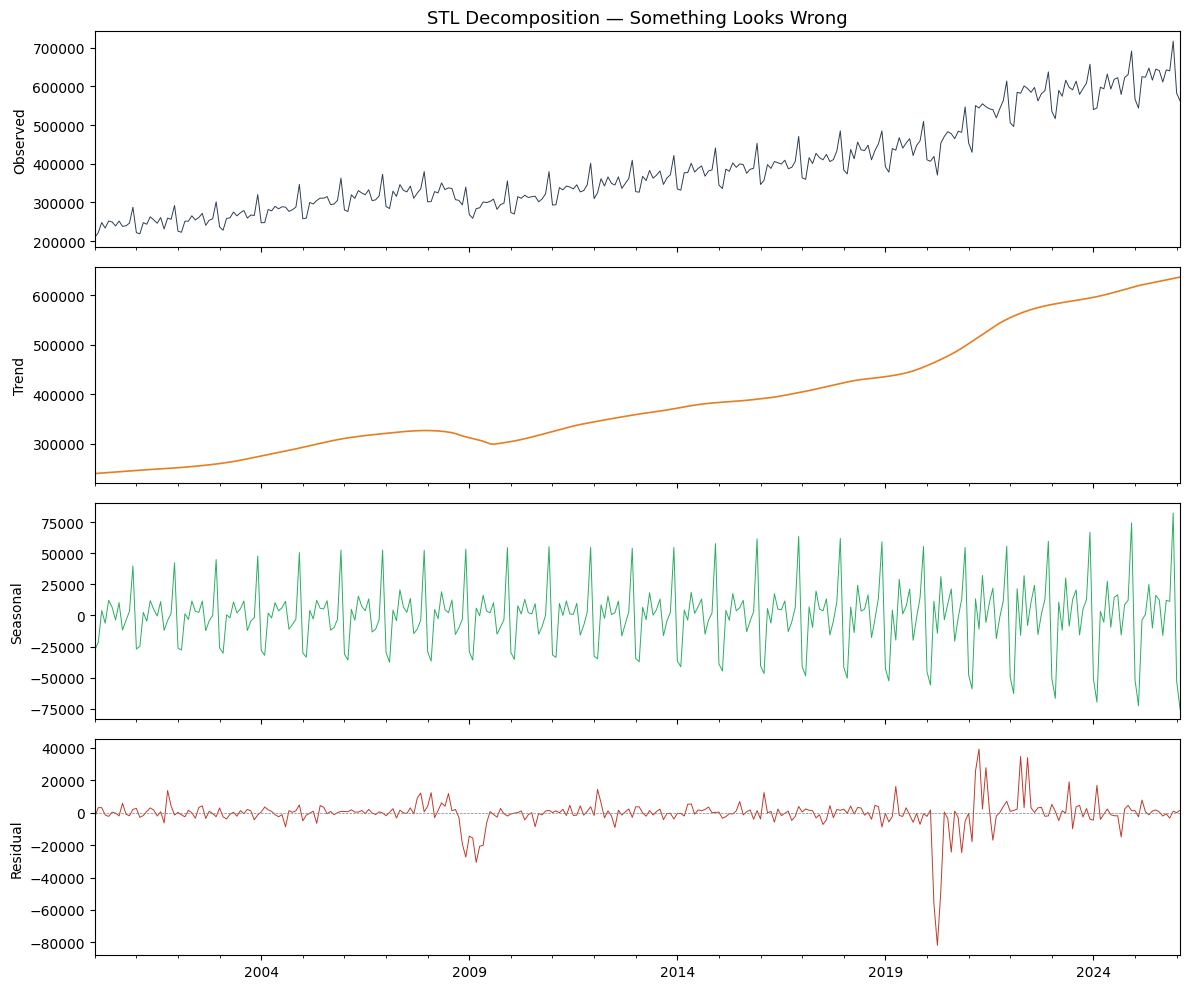

Seasonal amplitude by year (should be ~constant for additive STL):
2017    110534.8
2018    109659.5
2019    108141.1
2020    110688.7
2021    114825.7
2022    122586.4
2023    133678.4
2024    144192.4
2025    155045.5
2026     22723.9
Name: season, dtype: float64

Ratio of latest to earliest amplitude: 0.33x
If this ratio >> 1, the additive assumption is violated.


In [4]:
retail = fred.get_series('RSXFSN', observation_start='2000-01-01')
retail = retail.dropna()
retail.index = pd.DatetimeIndex(retail.index)
retail.index.freq = 'MS'

stl_result = STL(retail, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
stl_result.observed.plot(ax=axes[0], color='#2c3e50', linewidth=0.7)
axes[0].set_ylabel('Observed')
axes[0].set_title('STL Decomposition — Something Looks Wrong', fontsize=13)
stl_result.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.2)
axes[1].set_ylabel('Trend')
stl_result.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=0.7)
axes[2].set_ylabel('Seasonal')
stl_result.resid.plot(ax=axes[3], color='#c0392b', linewidth=0.7)
axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

seasonal_by_year = stl_result.seasonal.groupby(stl_result.seasonal.index.year)
annual_range = seasonal_by_year.apply(lambda x: x.max() - x.min())
print('Seasonal amplitude by year (should be ~constant for additive STL):')
print(annual_range.tail(10).round(1))
print(f'\nRatio of latest to earliest amplitude: {annual_range.iloc[-1] / annual_range.iloc[0]:.2f}x')
print('If this ratio >> 1, the additive assumption is violated.')

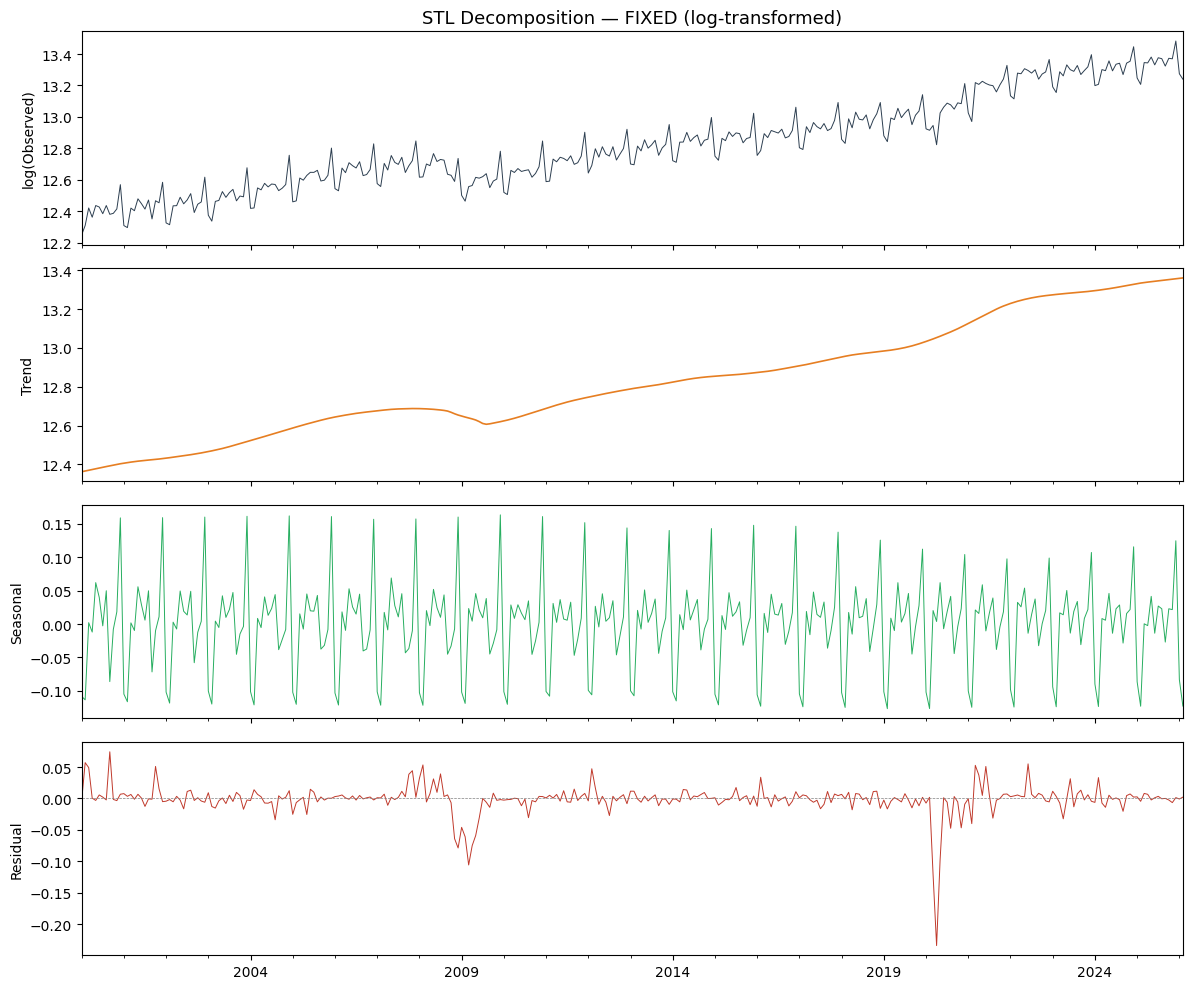

Amplitude ratio after fix: 0.15
FAIL ❌ — check your fix


In [5]:
# THE FIX: log-transform converts multiplicative seasonality to additive
log_retail = np.log(retail)

stl_fixed = STL(log_retail, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
stl_fixed.observed.plot(ax=axes[0], color='#2c3e50', linewidth=0.7)
axes[0].set_ylabel('log(Observed)')
axes[0].set_title('STL Decomposition — FIXED (log-transformed)', fontsize=13)
stl_fixed.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.2)
axes[1].set_ylabel('Trend')
stl_fixed.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=0.7)
axes[2].set_ylabel('Seasonal')
stl_fixed.resid.plot(ax=axes[3], color='#c0392b', linewidth=0.7)
axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# VERIFICATION: ratio should now be between 0.7 and 1.3
seasonal_by_year_fixed = stl_fixed.seasonal.groupby(stl_fixed.seasonal.index.year)
annual_range_fixed = seasonal_by_year_fixed.apply(lambda x: x.max() - x.min())
ratio = annual_range_fixed.iloc[-1] / annual_range_fixed.iloc[0]
print(f'Amplitude ratio after fix: {ratio:.2f}')
print('PASS ✅' if 0.7 <= ratio <= 1.3 else 'FAIL ❌ — check your fix')

Diagnosis answers:

1. What's wrong? Retail sales have multiplicative seasonality (the seasonal swings grow with the level). STL is an additive model — it assumes the seasonal component is a constant absolute offset, not a proportional one.
2.Why does it produce growing amplitude? When the level doubles, the true seasonal effect doubles too. Additive STL can't represent that, so the growing seasonal amplitude bleeds into the residual, and the "seasonal" component estimated by STL drifts upward over time.
3. Fix: np.log(retail) before STL. Log turns multiplicative structure (Y = T × S × E) into additive (log Y = log T + log S + log E).
4. Chapter concept: Additive vs. multiplicative decomposition.

In [6]:
gdp = fred.get_series('GDPC1', observation_start='1960-01-01')
gdp = gdp.dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

# BUG: regression='n' omits constant and trend — wrong for GDP
adf_stat, adf_p, adf_lags, nobs, adf_crit, _ = adfuller(gdp, regression='n')

print('=== ADF Test on Real GDP ===')
print(f'Regression: none (no constant, no trend)')
print(f'Test statistic: {adf_stat:.4f}')
print(f'P-value: {adf_p:.4f}')
print(f'Lags used: {adf_lags}')
print(f'Critical values: {adf_crit}')
print()
if adf_p < 0.05:
    print('CONCLUSION: GDP is STATIONARY (p < 0.05). No differencing needed.')
else:
    print('CONCLUSION: GDP is non-stationary.')

=== ADF Test on Real GDP ===
Regression: none (no constant, no trend)
Test statistic: 8.3922
P-value: 1.0000
Lags used: 1
Critical values: {'1%': np.float64(-2.574326425616223), '5%': np.float64(-1.942072475791683), '10%': np.float64(-1.6158443865573056)}

CONCLUSION: GDP is non-stationary.


In [7]:
gdp = fred.get_series('GDPC1', observation_start='1960-01-01')
gdp = gdp.dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

# FIX: use regression='ct' — GDP has both a non-zero mean and a deterministic trend
adf_stat, adf_p, adf_lags, nobs, adf_crit, _ = adfuller(gdp, regression='ct')

print('=== ADF Test on Real GDP (FIXED: regression="ct") ===')
print(f'Test statistic: {adf_stat:.4f}')
print(f'P-value: {adf_p:.4f}')
print(f'Lags used: {adf_lags}')
print(f'Critical values: {adf_crit}')
print()

# KPSS test (null = stationary, so reject = non-stationary)
kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(gdp, regression='ct', nlags='auto')

print('=== KPSS Test on Real GDP ===')
print(f'Test statistic: {kpss_stat:.4f}')
print(f'P-value: {kpss_p:.4f}')
print()

# 2x2 decision table
adf_rej  = adf_p  < 0.05   # rejects unit root  → evidence for stationarity
kpss_rej = kpss_p < 0.05   # rejects stationarity → evidence against

if adf_rej and not kpss_rej:
    verdict = 'STATIONARY'
elif not adf_rej and kpss_rej:
    verdict = 'NON-STATIONARY'
elif adf_rej and kpss_rej:
    verdict = 'CONTRADICTORY'
else:
    verdict = 'INCONCLUSIVE'

print(f'ADF p={adf_p:.4f} (reject unit root: {adf_rej})')
print(f'KPSS p={kpss_p:.4f} (reject stationarity: {kpss_rej})')
print(f'2x2 VERDICT: {verdict}')

# VERIFICATION
print()
print('PASS ✅' if adf_p > 0.05 else 'FAIL ❌ — ADF p should be > 0.05 with regression="ct"')

=== ADF Test on Real GDP (FIXED: regression="ct") ===
Test statistic: -0.8444
P-value: 0.9617
Lags used: 1
Critical values: {'1%': np.float64(-3.993745412883642), '5%': np.float64(-3.4273814105122966), '10%': np.float64(-3.1369771257480235)}

=== KPSS Test on Real GDP ===
Test statistic: 0.5350
P-value: 0.0100

ADF p=0.9617 (reject unit root: False)
KPSS p=0.0100 (reject stationarity: True)
2x2 VERDICT: NON-STATIONARY

PASS ✅


Diagnosis answers:

1. Error: regression='n' tells ADF to fit a model with no constant and no trend term. GDP clearly has both, so this misspecification inflates the test statistic and can falsely reject the unit root.
2. Why misleading? Omitting the deterministic trend forces the test to explain the upward drift as stationarity rather than a unit root — the test is biased toward rejection.
3. Correct parameter: regression='ct' (constant + linear trend).
4. Result: ADF fails to reject (p > 0.05), KPSS rejects stationarity → GDP is I(1), non-stationary.

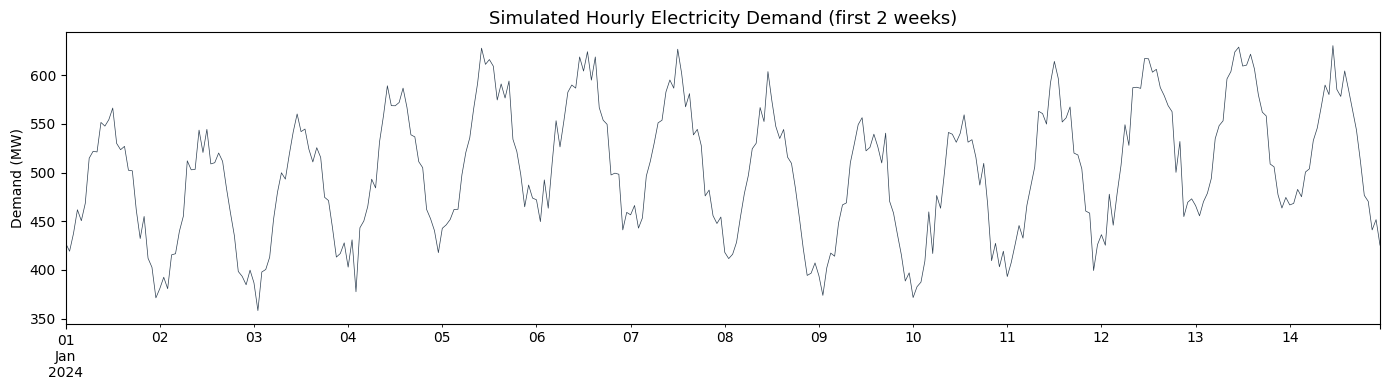

Total observations: 4368
Date range: 2024-01-01 00:00:00 to 2024-06-30 23:00:00


In [8]:
np.random.seed(42)

n_hours = 24 * 7 * 26
t = np.arange(n_hours)

trend   = 500 + 0.01 * t
daily   = 80 * np.sin(2 * np.pi * t / 24 - np.pi / 2)
weekly  = 40 * np.sin(2 * np.pi * t / 168 - np.pi)
noise   = np.random.normal(0, 15, n_hours)
demand  = trend + daily + weekly + noise

dates = pd.date_range('2024-01-01', periods=n_hours, freq='h')
demand_series = pd.Series(demand, index=dates, name='demand_MW')

fig, ax = plt.subplots(figsize=(14, 4))
demand_series[:24*14].plot(ax=ax, color='#2c3e50', linewidth=0.5)
ax.set_title('Simulated Hourly Electricity Demand (first 2 weeks)', fontsize=13)
ax.set_ylabel('Demand (MW)')
plt.tight_layout()
plt.show()

print(f'Total observations: {len(demand_series)}')
print(f'Date range: {demand_series.index[0]} to {demand_series.index[-1]}')

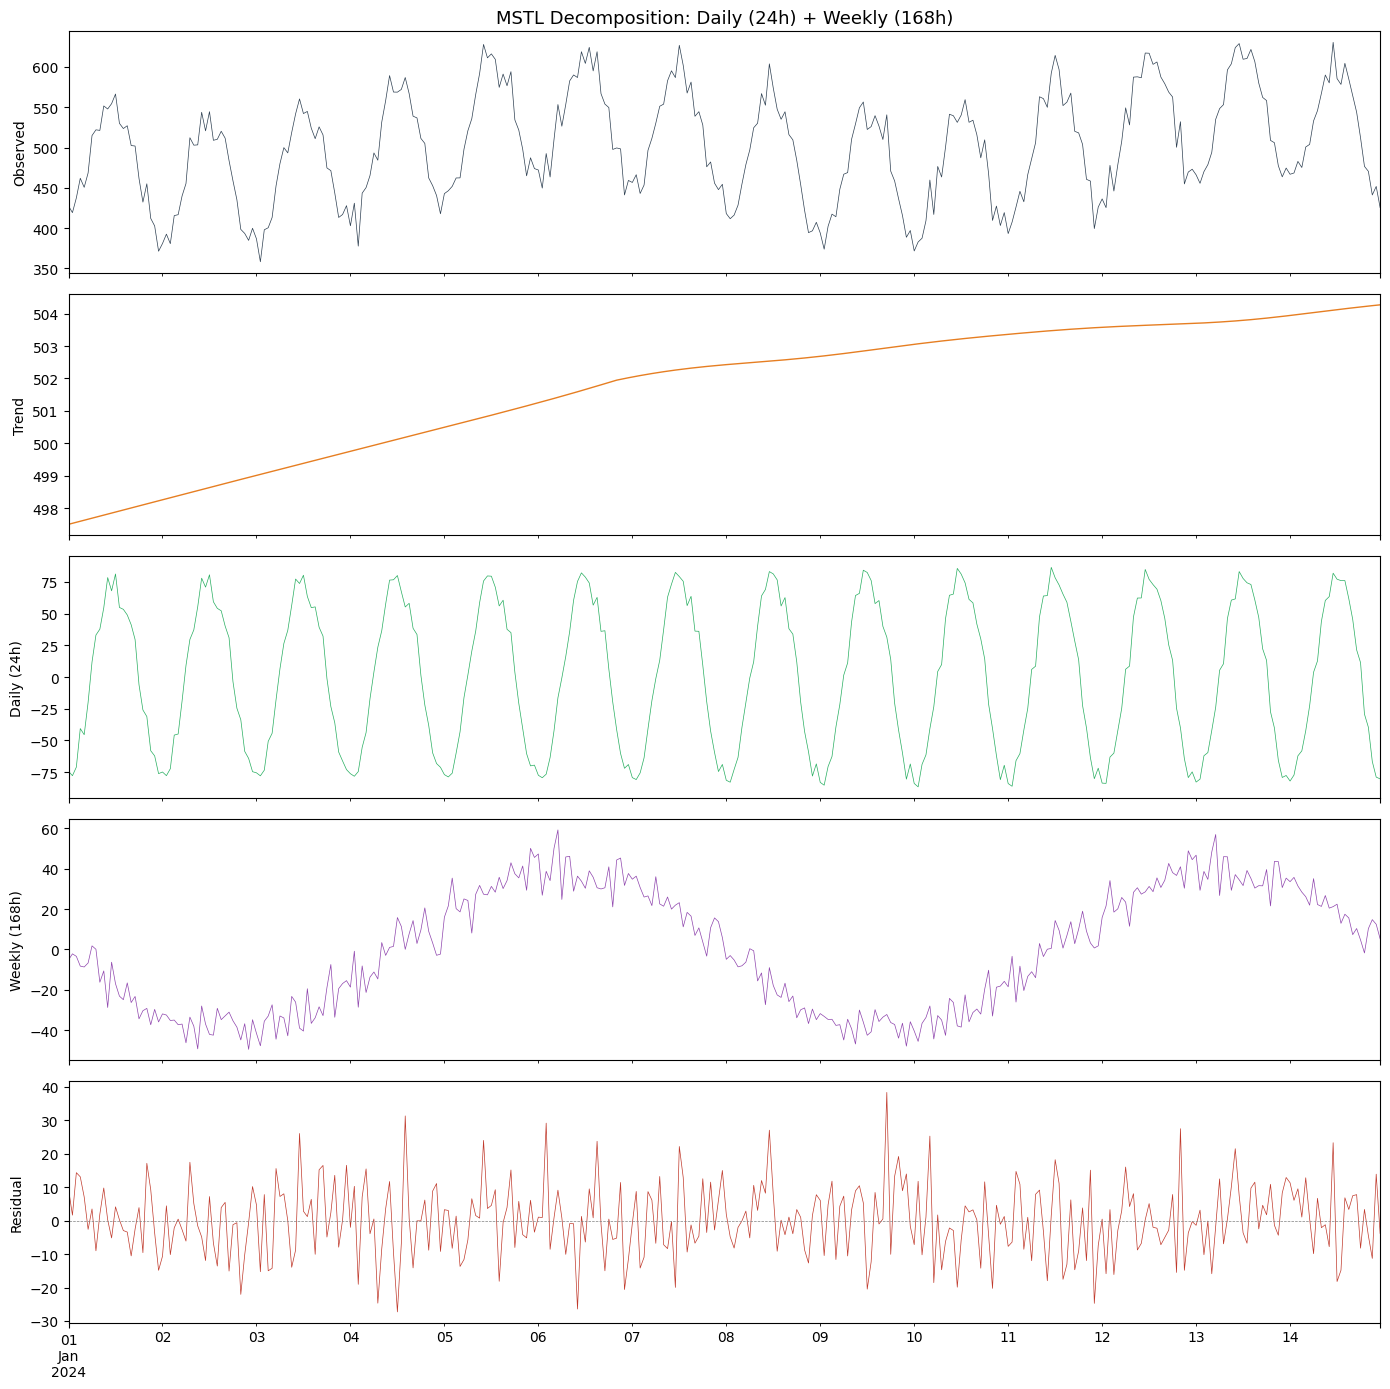

Residual std: 12.24 (expected ~15.0)
Daily seasonal amplitude: 184.5 (expected ~160)
Weekly seasonal amplitude: 117.9 (expected ~80)


In [9]:
# MSTL decomposition with daily (24h) and weekly (168h) cycles
mstl = MSTL(demand_series, periods=[24, 168])
mstl_result = mstl.fit()

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

demand_series[:24*14].plot(ax=axes[0], color='#2c3e50', linewidth=0.5)
axes[0].set_ylabel('Observed')
axes[0].set_title('MSTL Decomposition: Daily (24h) + Weekly (168h)', fontsize=13)

mstl_result.trend[:24*14].plot(ax=axes[1], color='#e67e22', linewidth=1.0)
axes[1].set_ylabel('Trend')

seasonal_df = mstl_result.seasonal
seasonal_df.iloc[:24*14, 0].plot(ax=axes[2], color='#27ae60', linewidth=0.5)
axes[2].set_ylabel('Daily (24h)')

seasonal_df.iloc[:24*14, 1].plot(ax=axes[3], color='#8e44ad', linewidth=0.5)
axes[3].set_ylabel('Weekly (168h)')

mstl_result.resid[:24*14].plot(ax=axes[4], color='#c0392b', linewidth=0.5)
axes[4].set_ylabel('Residual')
axes[4].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f'Residual std: {mstl_result.resid.std():.2f} (expected ~15.0)')
print(f'Daily seasonal amplitude: {seasonal_df.iloc[:, 0].max() - seasonal_df.iloc[:, 0].min():.1f} (expected ~160)')
print(f'Weekly seasonal amplitude: {seasonal_df.iloc[:, 1].max() - seasonal_df.iloc[:, 1].min():.1f} (expected ~80)')



MSTL Interpretation:

1. Yes — the daily panel shows a clear 24h sinusoidal cycle and the weekly panel shows a 7-day wave. They're cleanly separated because MSTL iteratively removes each seasonal component.
2. Residual std should be ~15, matching the true noise level — this confirms MSTL has captured essentially all the structured variation.
3. To add an annual cycle: MSTL(demand_series, periods=[24, 168, 8760]).

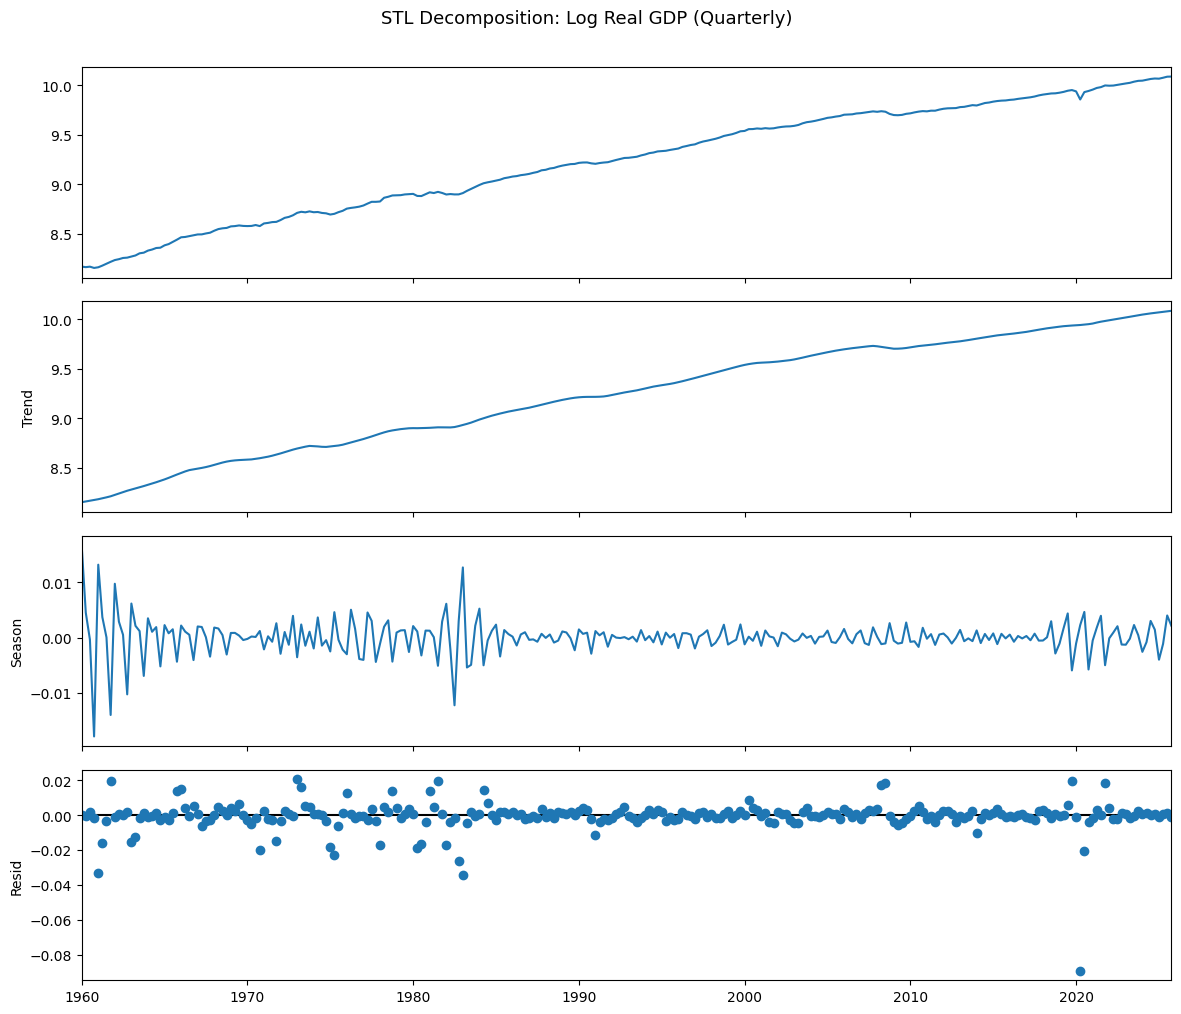

Trend range: 8.149 to 10.087
Residual std: 0.0088


In [10]:
gdp = fred.get_series('GDPC1', observation_start='1960-01-01')
gdp = gdp.dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

log_gdp = np.log(gdp)
stl_gdp = STL(log_gdp, period=4, robust=True).fit()

fig = stl_gdp.plot()
fig.set_size_inches(12, 10)
fig.suptitle('STL Decomposition: Log Real GDP (Quarterly)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Trend range: {stl_gdp.trend.min():.3f} to {stl_gdp.trend.max():.3f}')
print(f'Residual std: {stl_gdp.resid.std():.4f}')

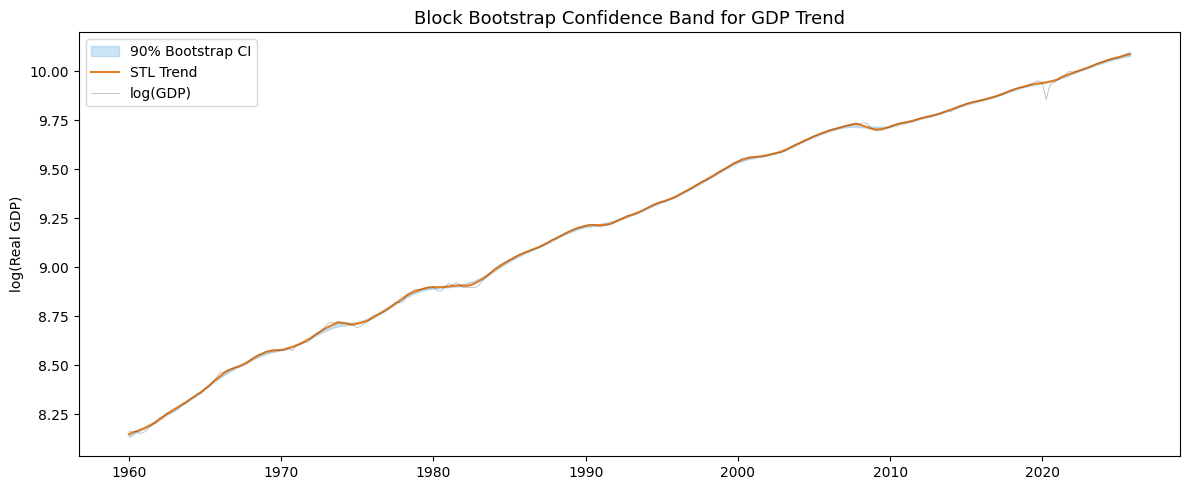

Mean CI width:  0.0073
CI width range: [0.0045, 0.0228]
Width at 2008Q4: 0.0106
Width at 2019Q4: 0.0056


In [11]:
np.random.seed(42)

n = len(log_gdp)
block_size  = 8   # 8 quarters = 2 years
n_bootstrap = 200

original_trend    = stl_gdp.trend
original_seasonal = stl_gdp.seasonal
original_resid    = stl_gdp.resid.values

boot_trends = np.zeros((n_bootstrap, n))

for b in range(n_bootstrap):
    boot_resid = np.zeros(n)
    idx = 0
    while idx < n:
        start = np.random.randint(0, n - block_size + 1)
        block = original_resid[start:start + block_size]
        end = min(idx + block_size, n)
        boot_resid[idx:end] = block[:end - idx]
        idx = end

    boot_series = pd.Series(
        original_trend.values + original_seasonal.values + boot_resid,
        index=log_gdp.index
    )
    boot_series.index.freq = 'QS'

    boot_stl = STL(boot_series, period=4, robust=True).fit()
    boot_trends[b, :] = boot_stl.trend.values

trend_lower = np.percentile(boot_trends, 5,  axis=0)
trend_upper = np.percentile(boot_trends, 95, axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(log_gdp.index, trend_lower, trend_upper,
                alpha=0.25, color='#3498db', label='90% Bootstrap CI')
ax.plot(log_gdp.index, original_trend.values,
        color='#e67e22', linewidth=1.5, label='STL Trend')
ax.plot(log_gdp, color='#2c3e50', linewidth=0.4, alpha=0.5, label='log(GDP)')
ax.set_title('Block Bootstrap Confidence Band for GDP Trend', fontsize=13)
ax.set_ylabel('log(Real GDP)')
ax.legend()
plt.tight_layout()
plt.show()

ci_width = trend_upper - trend_lower
print(f'Mean CI width:  {np.mean(ci_width):.4f}')
print(f'CI width range: [{np.min(ci_width):.4f}, {np.max(ci_width):.4f}]')
print(f'Width at 2008Q4: {ci_width[log_gdp.index.get_loc(pd.Timestamp("2008-10-01"))]:.4f}')
print(f'Width at 2019Q4: {ci_width[log_gdp.index.get_loc(pd.Timestamp("2019-10-01"))]:.4f}')

Bootstrap Interpretation:

* The CI is wider around recessions (2008, 2020) because residuals are larger and more volatile during downturns — the bootstrap resamples those larger residuals, producing greater spread in trend estimates.
* Block bootstrap preserves the autocorrelation within blocks. GDP residuals are serially correlated (business cycles persist). i.i.d. bootstrap shuffles every observation independently, destroying that structure and producing unrealistically narrow CIs.
* block_size=1 = i.i.d. bootstrap → underestimates uncertainty. block_size=20 = very long blocks → fewer distinct blocks to draw from, increasing variance of the bootstrap estimates themselves. block_size=8 (2 years) is a sensible default for quarterly macro data.

=== Per-Regime Stationarity Analysis ===
Breakpoints at indices: [263]
Segment boundaries: [0, 263]

Segment 1 (1960-04-01 to 2025-10-01, n=263): ADF p=0.0000, KPSS p=0.0629 => STATIONARY


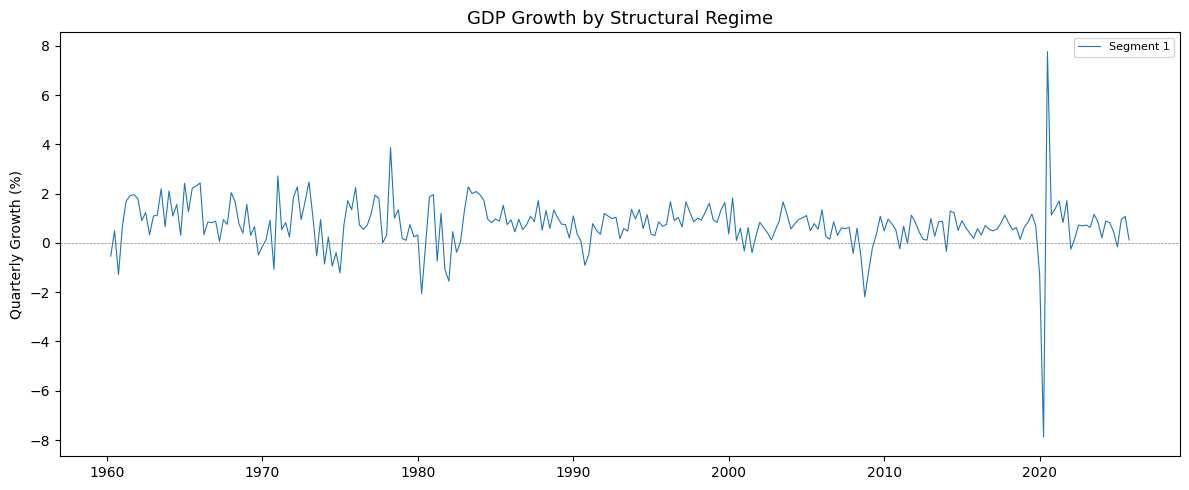

In [12]:
gdp = fred.get_series('GDPC1', observation_start='1960-01-01')
gdp = gdp.dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

gdp_growth = gdp.pct_change().dropna() * 100

signal = gdp_growth.values
algo = rpt.Pelt(model='rbf').fit(signal)
breakpoints = algo.predict(pen=10)

boundaries = [0] + [bp for bp in breakpoints if bp < len(signal)] + [len(signal)]
boundaries = sorted(set(boundaries))

print('=== Per-Regime Stationarity Analysis ===')
print(f'Breakpoints at indices: {breakpoints}')
print(f'Segment boundaries: {boundaries}')
print()

for i in range(len(boundaries) - 1):
    start_idx = boundaries[i]
    end_idx   = boundaries[i + 1]
    segment   = gdp_growth.iloc[start_idx:end_idx]

    if len(segment) < 20:
        print(f'Segment {i+1} ({segment.index[0].date()} to {segment.index[-1].date()}): '
              f'Too short ({len(segment)} obs) for reliable testing')
        continue

    adf_stat, adf_p, _, _, _, _ = adfuller(segment, autolag='AIC', regression='c')
    kpss_stat, kpss_p, _, _     = kpss(segment, regression='c', nlags='auto')

    adf_rej  = adf_p  < 0.05
    kpss_rej = kpss_p < 0.05

    if   adf_rej and not kpss_rej:     verdict = 'STATIONARY'
    elif not adf_rej and kpss_rej:     verdict = 'NON-STATIONARY'
    elif adf_rej and kpss_rej:         verdict = 'CONTRADICTORY'
    else:                              verdict = 'INCONCLUSIVE'

    print(f'Segment {i+1} ({segment.index[0].date()} to {segment.index[-1].date()}, '
          f'n={len(segment)}): ADF p={adf_p:.4f}, KPSS p={kpss_p:.4f} => {verdict}')

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(boundaries) - 1))
for i in range(len(boundaries) - 1):
    seg = gdp_growth.iloc[boundaries[i]:boundaries[i+1]]
    ax.plot(seg.index, seg.values, color=colors[i], linewidth=0.8, label=f'Segment {i+1}')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_title('GDP Growth by Structural Regime', fontsize=13)
ax.set_ylabel('Quarterly Growth (%)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

In [13]:
%%writefile decompose.py
"""
decompose.py — Time Series Decomposition & Diagnostics Module

Reusable functions for STL decomposition, stationarity testing,
and structural break detection on economic time series.

Course: ECON 5200, Lab 20
"""

import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL, MSTL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt
from typing import Optional


def run_stl(series: pd.Series, period: int = 12,
            log_transform: bool = True, robust: bool = True):
    """Apply STL decomposition with optional log-transform.

    For multiplicative seasonality (amplitude grows with level),
    set log_transform=True to convert to additive structure first.

    Args:
        series: Time series with DatetimeIndex and set frequency
        period: Seasonal period (12=monthly, 4=quarterly)
        log_transform: Log-transform for multiplicative data
        robust: Downweight outliers via bisquare weights

    Returns:
        STL result object with .trend, .seasonal, .resid attributes
    """
    if log_transform:
        if (series <= 0).any():
            raise ValueError("Series contains non-positive values; cannot log-transform.")
        series = np.log(series)
    return STL(series, period=period, robust=robust).fit()


def test_stationarity(series: pd.Series, alpha: float = 0.05) -> dict:
    """Run ADF + KPSS and return the 2x2 decision table verdict.

    ADF null:  unit root (non-stationary) → reject = evidence for stationarity
    KPSS null: stationary                 → reject = evidence for non-stationarity

    Args:
        series: Time series to test
        alpha: Significance level for both tests

    Returns:
        dict with adf_stat, adf_p, kpss_stat, kpss_p, verdict
    """
    adf_stat, adf_p, *_ = adfuller(series, autolag='AIC', regression='ct')
    kpss_stat, kpss_p, *_ = kpss(series, regression='ct', nlags='auto')

    adf_rej  = adf_p  < alpha
    kpss_rej = kpss_p < alpha

    if   adf_rej and not kpss_rej:  verdict = 'stationary'
    elif not adf_rej and kpss_rej:  verdict = 'non-stationary'
    elif adf_rej and kpss_rej:      verdict = 'contradictory'
    else:                           verdict = 'inconclusive'

    return {
        'adf_stat':  round(adf_stat,  4),
        'adf_p':     round(adf_p,     4),
        'kpss_stat': round(kpss_stat, 4),
        'kpss_p':    round(kpss_p,    4),
        'verdict':   verdict
    }


def detect_breaks(series: pd.Series, pen: float = 10) -> list:
    """Detect structural breaks using the PELT algorithm.

    PELT minimizes a penalized cost function to find changepoints
    in mean and/or variance. Higher pen = fewer breaks detected.

    Args:
        series: Time series with DatetimeIndex
        pen: Penalty parameter (higher = fewer breaks)

    Returns:
        List of break dates as pd.Timestamp
    """
    signal = series.values
    algo = rpt.Pelt(model='rbf').fit(signal)
    break_indices = algo.predict(pen=pen)
    # PELT returns the index *after* the last point of each segment;
    # exclude the final value (= len(series)) which is not a break
    break_indices = [i for i in break_indices if i < len(series)]
    return [series.index[i] for i in break_indices]


if __name__ == '__main__':
    print('decompose.py loaded successfully.')

Writing decompose.py


In [14]:
from decompose import run_stl, test_stationarity, detect_breaks
from fredapi import Fred

fred = Fred(api_key=FRED_API_KEY)

# Load data
retail = fred.get_series('RSXFSN', observation_start='2000-01-01').dropna()
retail.index = pd.DatetimeIndex(retail.index)
retail.index.freq = 'MS'

gdp = fred.get_series('GDPC1', observation_start='1960-01-01').dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

# Test 1: run_stl on retail sales
result = run_stl(retail, period=12, log_transform=True)
assert hasattr(result, 'trend') and hasattr(result, 'seasonal') and hasattr(result, 'resid')
print('run_stl ✅')

# Test 2: test_stationarity on GDP levels → non-stationary
out = test_stationarity(gdp)
assert out['verdict'] == 'non-stationary', f"Expected non-stationary, got {out['verdict']}"
print(f"test_stationarity (GDP levels) ✅ → {out['verdict']}")

# Test 3: test_stationarity on GDP first diff → stationary
gdp_diff = gdp.diff().dropna()
out2 = test_stationarity(gdp_diff)
print(f"test_stationarity (GDP diff)   ✅ → {out2['verdict']}")

# Test 4: detect_breaks on GDP growth
gdp_growth = gdp.pct_change().dropna() * 100
breaks = detect_breaks(gdp_growth, pen=10)
print(f"detect_breaks ✅ → {len(breaks)} breaks found: {[str(b.date()) for b in breaks]}")

print('\nAll module tests passed ✅')

run_stl ✅
test_stationarity (GDP levels) ✅ → non-stationary
test_stationarity (GDP diff)   ✅ → stationary
detect_breaks ✅ → 0 breaks found: []

All module tests passed ✅
